<a href="https://colab.research.google.com/github/np03cs4a230006-dotcom/Ai-and-Ml/blob/main/Workshop_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Required Libraries

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, Activation, GlobalAveragePooling2D
)

from sklearn.metrics import classification_report, confusion_matrix


## 2. Define Dataset Path


In [3]:
train_dir = "/content/drive/MyDrive/Ai and Machine Learning/FruitinAmazon/FruitinAmazon/train"   # Change this to your dataset path

## 3. Read Class Names


In [4]:
class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


## 4. Check Corrupted Images


In [5]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = os.listdir(class_path)

        for img_name in images:
            img_path = os.path.join(class_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found.")


No corrupted images found.


## 5. Remove Corrupted Images


In [6]:
for img_path in corrupted_images:
    try:
        os.remove(img_path)
        print(f"Deleted: {img_path}")
    except Exception as e:
        print(f"Could not delete {img_path}: {e}")

## 6. Check Class Distribution


In [7]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)

for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")

print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


## 7. Visualize One Random Image from Each Class


In [8]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]

        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

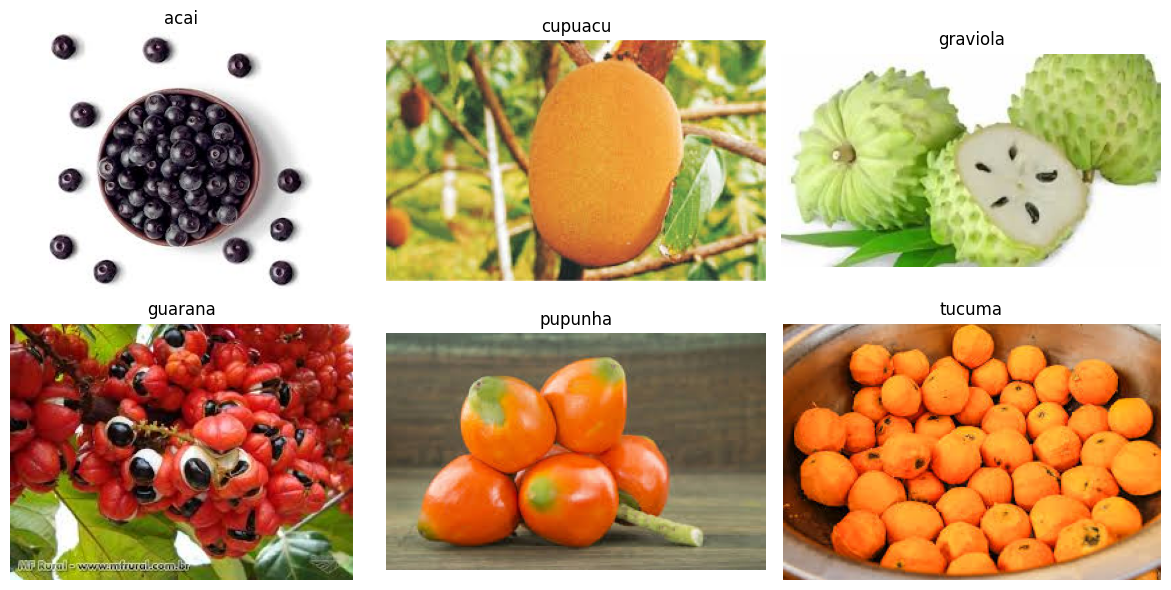

In [9]:
num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

## 8. Create Training and Validation Dataset


In [10]:
image_size = (224, 224)
batch_size = 32
seed = 1337

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


## 9. Check Dataset Shape


In [11]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


## 10. Visualize Sample Training Images


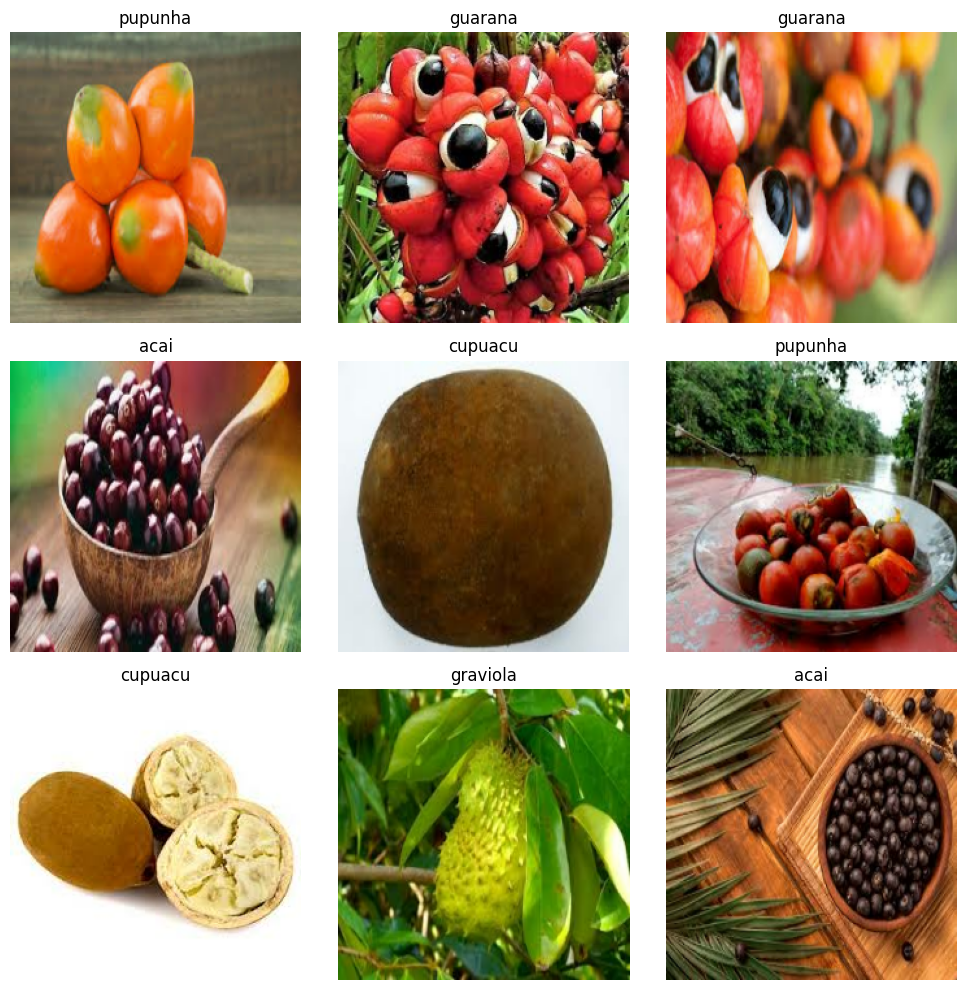

In [12]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.tight_layout()
plt.show()

## 11. Improve Dataset Performance


In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 12. Create Data Augmentation


In [14]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
], name="data_augmentation")

## 13. Visualize Augmented Images

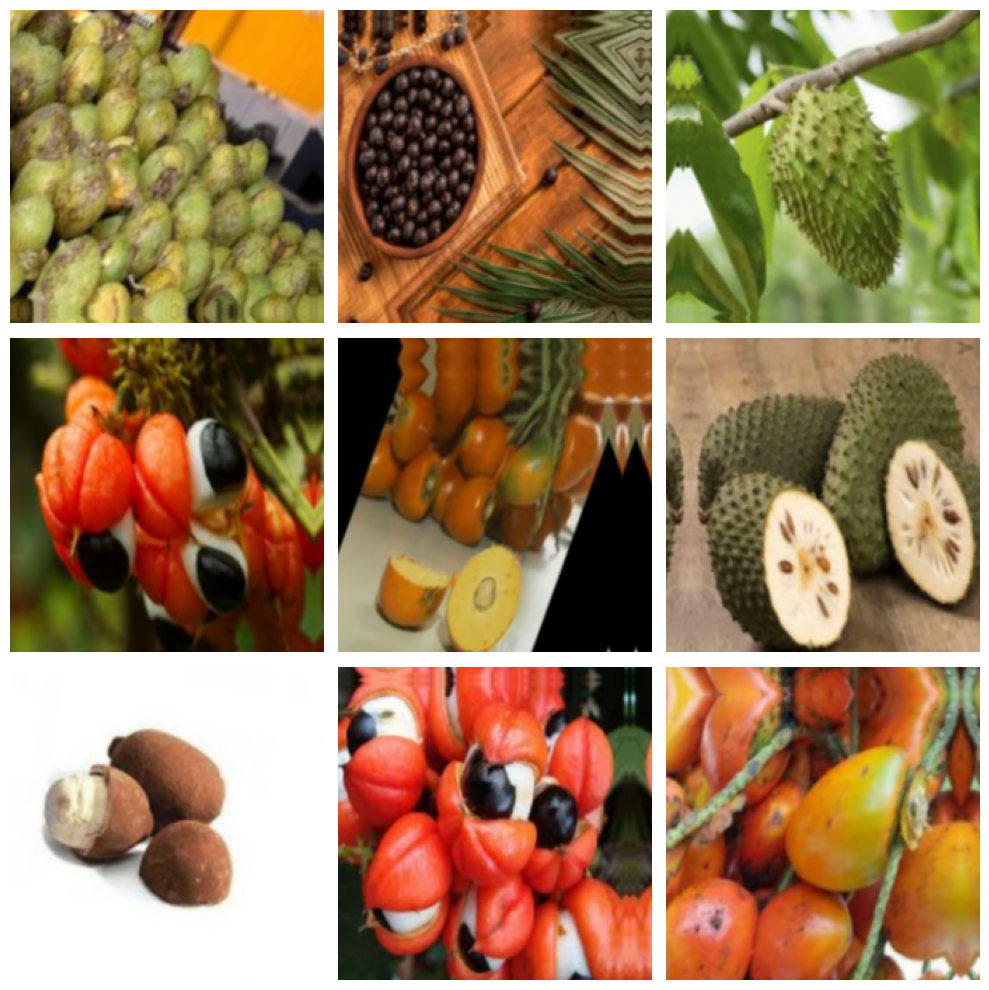

In [15]:
plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    augmented_images = data_augmentation(images)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")

plt.tight_layout()
plt.show()

## 14. Build CNN Model from Scratch


In [16]:
num_classes = len(class_names)

model = Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    layers.Rescaling(1.0 / 255),

    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),

    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

## 15. Compile the Model


In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 16. View Model Summary

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             

 Total params: 26,257,670 (100.17 MB)

 Trainable params: 26,254,790 (100.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

## 17. Train the Model


In [19]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 7s/step - accuracy: 0.1806 - loss: 2.1382 - val_accuracy: 0.0556 - val_loss: 1.8040
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.1944 - loss: 2.1877 - val_accuracy: 0.1111 - val_loss: 1.7799
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.1528 - loss: 2.1730 - val_accuracy: 0.1667 - val_loss: 1.7825
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.2083 - loss: 2.2053 - val_accuracy: 0.0556 - val_loss: 1.7875
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.1806 - loss: 2.0395 - val_accuracy: 0.0556 - val_loss: 1.7902
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 5s/step - accuracy: 0.2083 - loss: 1.9979 - val_accuracy: 0.1111 - val_loss: 1.7960
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 5s/step - accuracy: 0.2083 - loss: 2.2299 - val_accuracy: 0.2222 - val_loss: 1.8221
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.3194 - loss: 1.9530 - val_accuracy: 0.2222 - val_loss: 1.8622
Epoch 9/

## 18. Evaluate the Model


In [20]:
test_loss, test_acc = model.evaluate(val_ds)
print(f"Validation Loss: {test_loss:.4f}")
print(f"Validation Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.2222 - loss: 2.1579
Validation Loss: 2.1579
Validation Accuracy: 0.2222


## 19. Plot Accuracy Graph

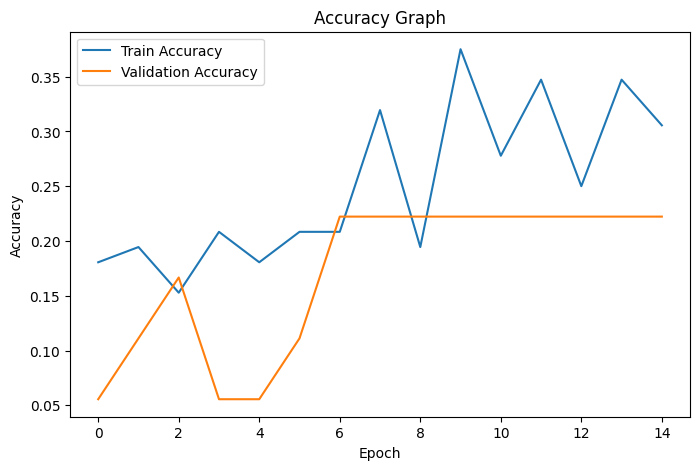

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 20. Plot Loss Graph

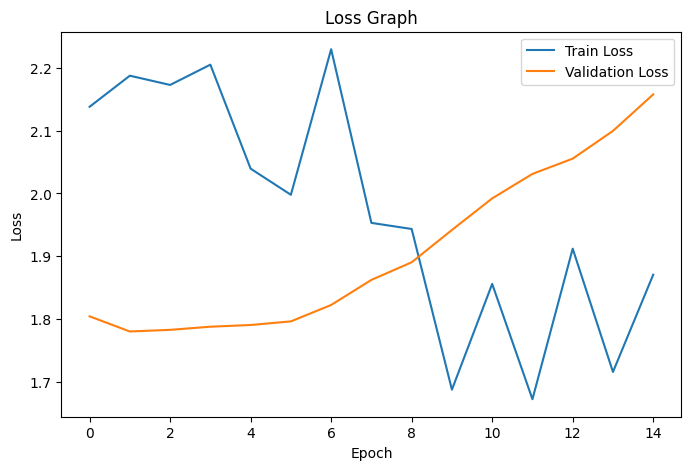

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Graph')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 21. Save the Model


In [23]:
model.save("cnn_fruit_model.keras")
print("Model saved successfully.")

Model saved successfully.


## 22. Load the Saved Model

In [24]:
loaded_model = tf.keras.models.load_model("cnn_fruit_model.keras")
print("Model loaded successfully.")

Model loaded successfully.


## 23. Compile Loaded Model

In [25]:
loaded_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 24. Re-evaluate Loaded Model

In [26]:
loaded_model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 997ms/step - accuracy: 0.2222 - loss: 2.1579


[2.157902479171753, 0.2222222238779068]

## 25. Make Predictions


In [27]:
for images, labels in val_ds.take(1):
    predictions = loaded_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    print("Predicted labels:", predicted_labels[:10])
    print("Actual labels:   ", labels.numpy()[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
Predicted labels: [1 1 1 1 1 1 1 1 1 1]
Actual labels:    [4 4 1 5 1 0 1 5 3 0]


## 26. Generate Classification Report


In [28]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = loaded_model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       0.22      1.00      0.36         4
    graviola       0.00      0.00      0.00         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.00      0.00      0.00         4
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.22        18
   macro avg       0.04      0.17      0.06        18
weighted avg       0.05      0.22      0.08        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 27. Display Confusion Matrix


In [29]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[0 3 0 0 0 0]
 [0 4 0 0 0 0]
 [0 1 0 0 0 0]
 [0 1 0 0 0 0]
 [0 4 0 0 0 0]
 [0 5 0 0 0 0]]


## 28. Predict a Single Image


In [31]:
img_path = "/content/drive/MyDrive/Ai and Machine Learning/FruitinAmazon/FruitinAmazon/train/graviola/download (5).jpeg"   # Change this path

img = keras.utils.load_img(img_path, target_size=(224, 224))
img_array = keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = loaded_model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

print("Predicted class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted class: cupuacu


# Transfer Learning using VGG16
## 29. Load pre-trained VGG16 model


In [32]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 30. Freeze VGG16 Layers


In [33]:
for layer in base_model.layers:
    layer.trainable = False

## 31. Add Custom Classification Layers


In [34]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

## 32. Create Final Transfer Learning Model

In [35]:
transfer_model = Model(inputs=base_model.input, outputs=output)

## 33. Compile Transfer Learning Model

In [36]:
transfer_model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 34. Train Transfer Learning Model

In [37]:
history_tl = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 37s 12s/step - accuracy: 0.2639 - loss: 5.9654 - val_accuracy: 0.4444 - val_loss: 3.2721
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 36s 12s/step - accuracy: 0.9306 - loss: 0.3320 - val_accuracy: 0.3889 - val_loss: 3.6990
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 11s/step - accuracy: 0.8056 - loss: 0.9111 - val_accuracy: 0.6111 - val_loss: 4.0025
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 42s 12s/step - accuracy: 0.9722 - loss: 0.1931 - val_accuracy: 0.5000 - val_loss: 4.7702
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 11s/step - accuracy: 0.9861 - loss: 0.0337 - val_accuracy: 0.4444 - val_loss: 5.4444
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 37s 12s/step - accuracy: 0.9722 - loss: 0.0930 - val_accuracy: 0.5000 - val_loss: 5.0889
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 37s 12s/step - accuracy: 1.0000 - loss: 4.7737e-04 - val_accuracy: 0.5000 - val_loss: 4.5572
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 52s 18s/step - accuracy: 1.0000 - loss: 1.7490e-04 - val_accuracy: 0.5000 - val_loss:

## 35. Evaluate Transfer Learning Model

In [38]:
tl_loss, tl_acc = transfer_model.evaluate(val_ds)
print(f"Transfer Learning Validation Accuracy: {tl_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.5000 - loss: 4.3534
Transfer Learning Validation Accuracy: 0.5000


## 36. Classification Report for Transfer Learning

In [39]:
y_true_tl = []
y_pred_tl = []

for images, labels in val_ds:
    preds = transfer_model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_pred_tl.extend(preds)
    y_true_tl.extend(labels.numpy())

print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

              precision    recall  f1-score   support

        acai       1.00      0.33      0.50         3
     cupuacu       0.75      0.75      0.75         4
    graviola       0.33      1.00      0.50         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.50      0.50      0.50         4
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.50        18
   macro avg       0.51      0.50      0.45        18
weighted avg       0.60      0.50      0.51        18



## 37. Compare Both Models


In [40]:
print("CNN from scratch accuracy:", test_acc)
print("Transfer learning accuracy:", tl_acc)

CNN from scratch accuracy: 0.2222222238779068
Transfer learning accuracy: 0.5
